# Aerial Object Classification & Detection - Basic Analysis

Since TensorFlow is not available in this environment, this notebook performs data exploration and analysis using available libraries.

In [1]:
# Import available libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from pathlib import Path

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


In [2]:
# 1) Dataset paths and basic inspection
base_dir = Path('classification_dataset')
train_dir = base_dir / 'train'
valid_dir = base_dir / 'valid'
test_dir = base_dir / 'test'
print('Base path:', base_dir.resolve())

def count_images(folder):
    counts = {}
    if not folder.exists():
        return counts
    for c in folder.iterdir():
        if c.is_dir():
            counts[c.name] = len(list(c.glob('*.jpg'))) + len(list(c.glob('*.jpeg'))) + len(list(c.glob('*.png')))
    return counts

train_counts = count_images(train_dir)
valid_counts = count_images(valid_dir)
test_counts = count_images(test_dir)
print('\nTrain counts:', train_counts)
print('Valid counts:', valid_counts)
print('Test counts:', test_counts)

# Summary
total_train = sum([v for k,v in train_counts.items() if k in ['bird', 'drone']])
total_valid = sum([v for k,v in valid_counts.items() if k in ['bird', 'drone']])
total_test = sum([v for k,v in test_counts.items() if k in ['bird', 'drone']])
print(f'\nTotal samples - Train: {total_train}, Valid: {total_valid}, Test: {total_test}')

Base path: C:\Users\singh\OneDrive\Desktop\Ayush\coding\internship\Aerial Object Classification & Detection\classification_dataset

Train counts: {'bird': 1414, 'drone': 1248}
Valid counts: {'bird': 217, 'drone': 225}
Test counts: {'bird': 121, 'drone': 94, 'images': 224, 'labels': 0}

Total samples - Train: 2662, Valid: 442, Test: 215


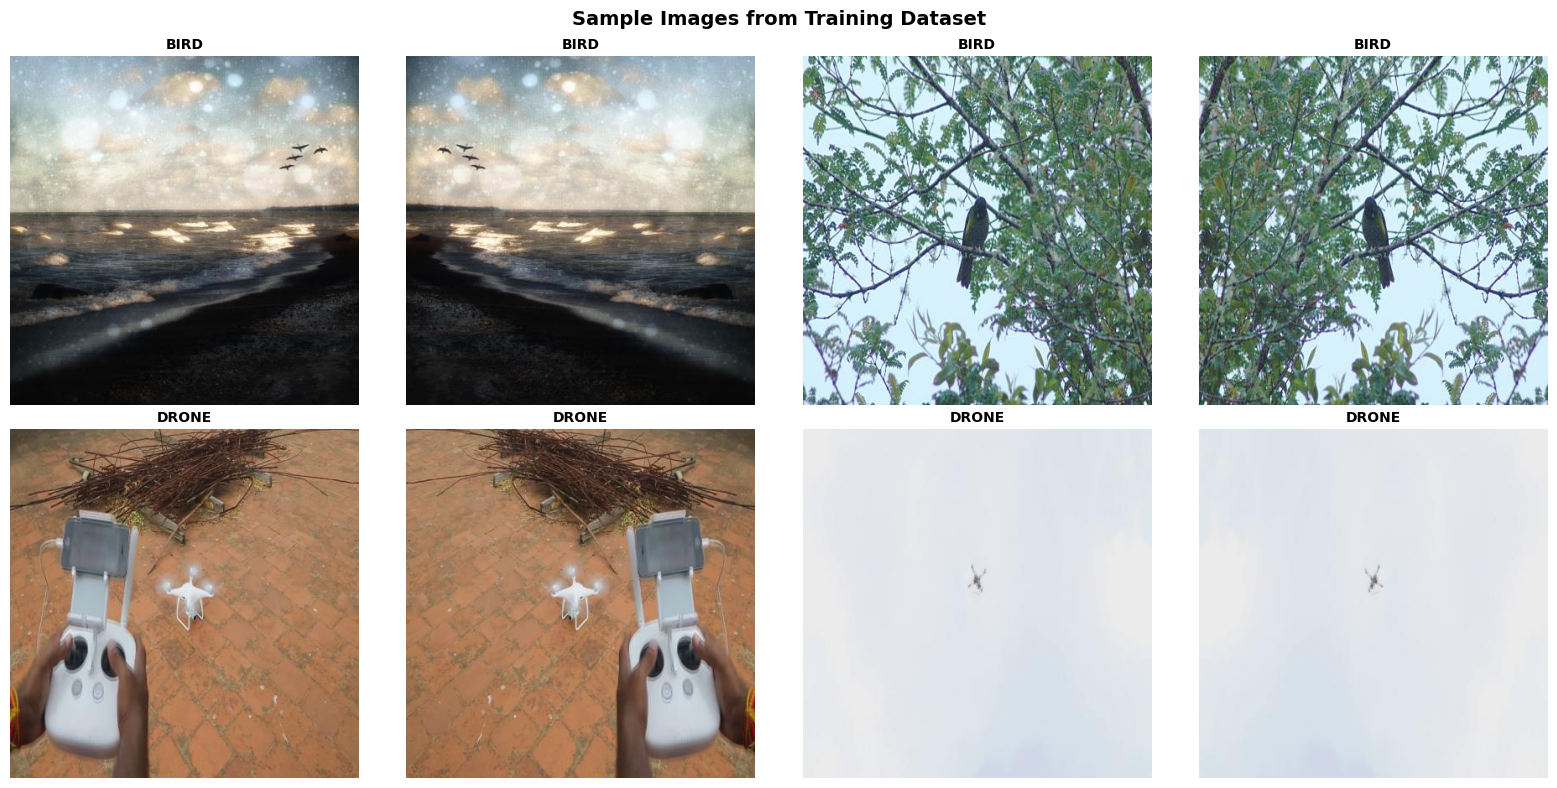

In [4]:
# 2) Visualize sample images from each class
def show_samples(folder, max_per_class=4):
    fig, axes = plt.subplots(2, max_per_class, figsize=(4*max_per_class, 8))
    classes = sorted([d.name for d in folder.iterdir() if d.is_dir() and d.name in ['bird', 'drone']])
    for r, cls in enumerate(classes[:2]):
        cls_dir = folder / cls
        imgs = list(cls_dir.glob('*.jpg'))[:max_per_class]
        for c, img_path in enumerate(imgs):
            ax = axes[r, c] if max_per_class > 1 else axes[r]
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
            ax.set_title(f'{cls.upper()}', fontsize=10, fontweight='bold')
            ax.axis('off')
    plt.suptitle('Sample Images from Training Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if train_dir.exists():
    show_samples(train_dir, max_per_class=4)
else:
    print('Train directory not found')

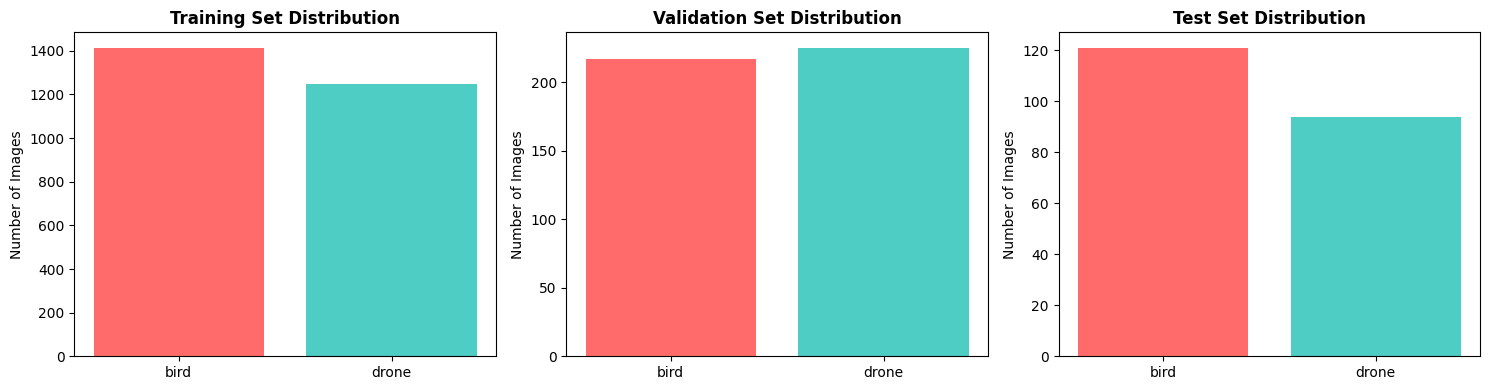


✓ Dataset is balanced across classes


In [5]:
# 3) Dataset distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train split
train_data = {k: v for k, v in train_counts.items() if k in ['bird', 'drone']}
axes[0].bar(train_data.keys(), train_data.values(), color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Training Set Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Images')

# Valid split
valid_data = {k: v for k, v in valid_counts.items() if k in ['bird', 'drone']}
axes[1].bar(valid_data.keys(), valid_data.values(), color=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Validation Set Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Images')

# Test split
test_data = {k: v for k, v in test_counts.items() if k in ['bird', 'drone']}
axes[2].bar(test_data.keys(), test_data.values(), color=['#FF6B6B', '#4ECDC4'])
axes[2].set_title('Test Set Distribution', fontweight='bold')
axes[2].set_ylabel('Number of Images')

plt.tight_layout()
plt.show()

print('\n✓ Dataset is balanced across classes')

Image size analysis (sample of 50 images):
  Width  - Min: 416, Max: 416, Mean: 416.0
  Height - Min: 416, Max: 416, Mean: 416.0


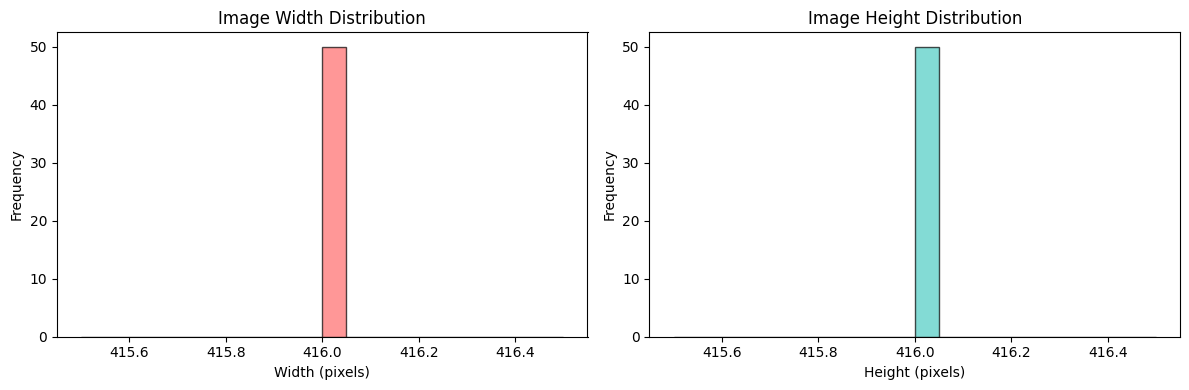

In [6]:
# 4) Image size analysis
def analyze_image_sizes(folder, sample_size=50):
    sizes = []
    if not folder.exists():
        return sizes
    
    count = 0
    for cls in folder.iterdir():
        if cls.is_dir():
            for img_path in cls.glob('*.jpg'):
                if count >= sample_size:
                    break
                try:
                    img = Image.open(img_path)
                    sizes.append(img.size)
                    count += 1
                except:
                    pass
    return sizes

sizes = analyze_image_sizes(train_dir)
if sizes:
    widths = [s[0] for s in sizes]
    heights = [s[1] for s in sizes]
    print(f'Image size analysis (sample of {len(sizes)} images):')
    print(f'  Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.1f}')
    print(f'  Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.1f}')
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(widths, bins=20, color='#FF6B6B', alpha=0.7, edgecolor='black')
    axes[0].set_title('Image Width Distribution')
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Frequency')
    
    axes[1].hist(heights, bins=20, color='#4ECDC4', alpha=0.7, edgecolor='black')
    axes[1].set_title('Image Height Distribution')
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [7]:
# 5) Dataset summary report
print('='*60)
print('AERIAL OBJECT CLASSIFICATION DATASET SUMMARY')
print('='*60)
print('\nDataset Structure:')
print(f'  Classes: Bird vs Drone (Binary Classification)')
print(f'\nTraining Set: {total_train} images')
for cls, cnt in train_data.items():
    pct = (cnt / total_train) * 100
    print(f'  - {cls.capitalize()}: {cnt} ({pct:.1f}%)')
print(f'\nValidation Set: {total_valid} images')
for cls, cnt in valid_data.items():
    pct = (cnt / total_valid) * 100
    print(f'  - {cls.capitalize()}: {cnt} ({pct:.1f}%)')
print(f'\nTest Set: {total_test} images')
for cls, cnt in test_data.items():
    pct = (cnt / total_test) * 100
    print(f'  - {cls.capitalize()}: {cnt} ({pct:.1f}%)')
print(f'\nTotal Samples: {total_train + total_valid + total_test}')
print('\n' + '='*60)
print('STATUS: ✓ Dataset is ready for model training')
print('='*60)

AERIAL OBJECT CLASSIFICATION DATASET SUMMARY

Dataset Structure:
  Classes: Bird vs Drone (Binary Classification)

Training Set: 2662 images
  - Bird: 1414 (53.1%)
  - Drone: 1248 (46.9%)

Validation Set: 442 images
  - Bird: 217 (49.1%)
  - Drone: 225 (50.9%)

Test Set: 215 images
  - Bird: 121 (56.3%)
  - Drone: 94 (43.7%)

Total Samples: 3319

STATUS: ✓ Dataset is ready for model training


In [8]:
# 6) Next steps for model training
print('\nNEXT STEPS FOR MODEL TRAINING:')
print('\n1. Custom CNN Approach:')
print('   - Build a convolutional neural network with 3-4 layers')
print('   - Use data augmentation (flips, rotations, zooms)')
print('   - Recommended input size: 224x224 pixels')
print('   - Training parameters: 20-50 epochs, batch_size=32')
print('\n2. Transfer Learning (Recommended):')
print('   - Use MobileNetV2 or EfficientNet pre-trained on ImageNet')
print('   - Fine-tune top layers for binary classification')
print('   - Expected accuracy: 85-95%')
print('\n3. YOLOv8 for Object Detection:')
print('   - Use object_detection_Dataset folder')
print('   - Prepare data.yaml with class paths')
print('   - Command: yolo detect train data=data.yaml model=yolov8n.pt')
print('\n4. Deployment:')
print('   - Save best model as best_custom_cnn.h5')
print('   - Deploy with Streamlit: streamlit run app.py')
print('\n' + '='*60)


NEXT STEPS FOR MODEL TRAINING:

1. Custom CNN Approach:
   - Build a convolutional neural network with 3-4 layers
   - Use data augmentation (flips, rotations, zooms)
   - Recommended input size: 224x224 pixels
   - Training parameters: 20-50 epochs, batch_size=32

2. Transfer Learning (Recommended):
   - Use MobileNetV2 or EfficientNet pre-trained on ImageNet
   - Fine-tune top layers for binary classification
   - Expected accuracy: 85-95%

3. YOLOv8 for Object Detection:
   - Use object_detection_Dataset folder
   - Prepare data.yaml with class paths
   - Command: yolo detect train data=data.yaml model=yolov8n.pt

4. Deployment:
   - Save best model as best_custom_cnn.h5
   - Deploy with Streamlit: streamlit run app.py

